 [ 450 / 450 ] 100% - 0:00:00 left 
 quantization error: 0.1437230449803753


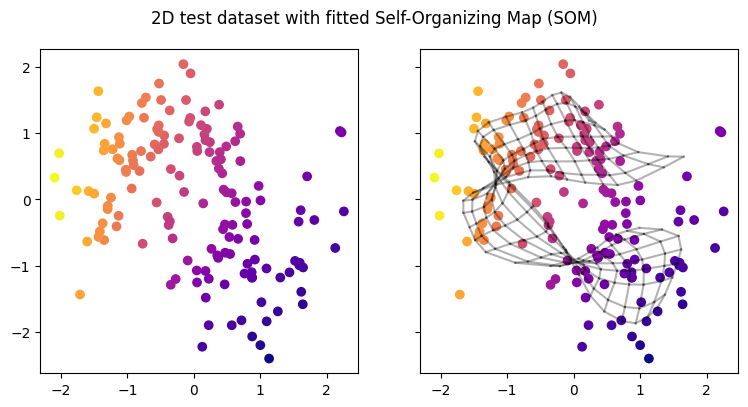

SOM quality:
Topographic error: 0.04
Quantization error: 0.1437


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

RAND = 42
CMAP = "plasma"

X, _ = make_moons(n_samples=(100, 50), noise=0.25, random_state=RAND)
X += abs(X.min())

theta = np.arctan2(X[:, 1], X[:, 0])
y = (theta - theta.min()) / (theta.max() - theta.min())

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from minisom import MiniSom
from som import place_node_edges
fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharex=True, sharey=True)

ax = axes[0]
ax.scatter(*X_scaled.T, c=y, cmap=CMAP)
ax.set_aspect("equal")

som = MiniSom(x=8, y=24, input_len=2, sigma=2.7, learning_rate=0.4, random_seed=RAND)
som.random_weights_init(X_scaled)
som.train(X_scaled, num_iteration=3, use_epochs=True, verbose=True)

ax = axes[1]
ax.scatter(*X_scaled.T, c=y, cmap=CMAP)
place_node_edges(som, ax=ax)
ax.set_aspect("equal")

plt.suptitle("2D test dataset with fitted Self-Organizing Map (SOM)")
plt.tight_layout()
plt.show()

print("SOM quality:")
print("Topographic error:", som.topographic_error(X_scaled).round(4))
print("Quantization error:", som.quantization_error(X_scaled).round(4))

In [11]:
from lilypond.basin import Basin

basin = Basin(som, X_scaled, random_seed=RAND).prepare()

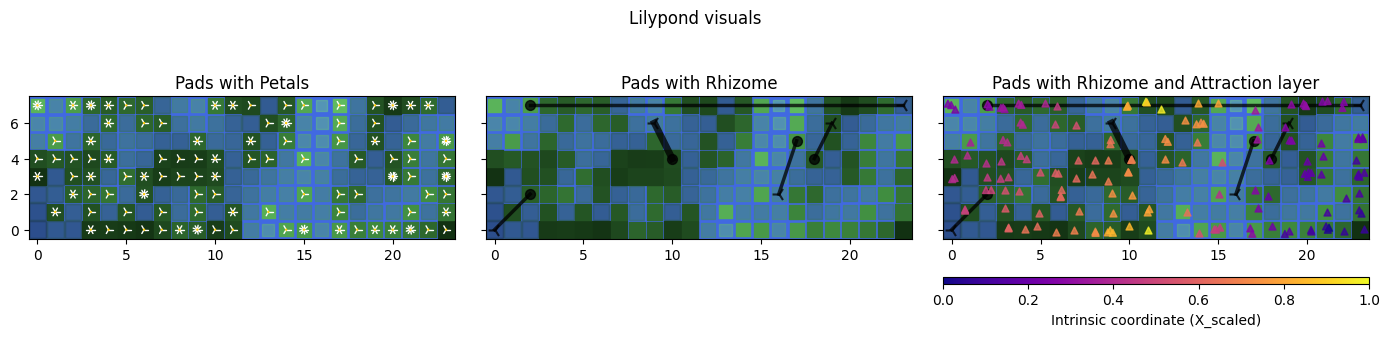

In [12]:
style_pad = {
    "marker": "s",
    "gap": .32,
}

style_petal = {
    "size_base": .5,
    "width": 1,
}

style_rhizome = {
    "zorder": 11,
	"opacity": .75,
	"linewidth": 2.5,
}

style_attract = {
    "cmap": CMAP,
    "cmap_values": y,
    "cmap_label": "Intrinsic coordinate",
    "label": "X_scaled",
    "zorder": 12,
    "marker": "^",
    "size_base": 25,
    "opacity": .8,
    "subsample_ratio": None,
}

fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(14, 3), sharex=True, sharey=True)

pond = basin.pond() \
	.style_pad(**style_pad) \
	.style_petal(**style_petal) \
	.style_rhizome(**style_rhizome) \
	.set_coloring_strategy("distance_map") \
	.flood(below_activations=1)

# visual 1
pond \
	.observe(return_fig=True, ax=ax0, title="Pads with Petals")

pond.style_petal(hide=True)

# visual 2
pond \
	.see_rhizome(ax=ax1) \
	.observe(return_fig=True, ax=ax1, title="Pads with Rhizome")

# visual 3
pond \
	.see_rhizome(ax=ax2) \
	.attract(X_scaled, **style_attract) \
	.observe(return_fig=True, ax=ax2, title="Pads with Rhizome and Attraction layer")

plt.suptitle("Lilypond visuals")
plt.tight_layout()
plt.show()

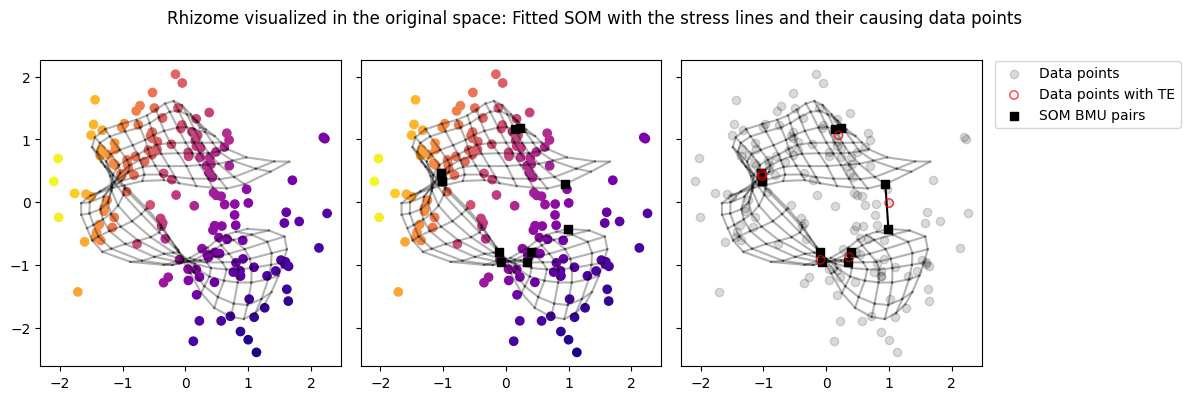

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)

ax = axes[0]
ax.scatter(*X_scaled.T, c=y, cmap=CMAP)
place_node_edges(som, ax=ax)
ax.set_aspect("equal")

ax = axes[1]
node_weights = som.get_weights()
node_weights_flat = node_weights.reshape(-1, node_weights.shape[-1])

all_affected_data_points_idx_ = pond.rhizome_affected_data_points_idx_
all_node_coords_with_rhizome_flat = pond.rhizome_b2mu_coords_flat_shown_.flatten()
all_node_weights_with_rhizome_flat = np.array([(node_weights_flat[bmu1], node_weights_flat[bmu2]) for (bmu1, bmu2) in pond.rhizome_b2mu_coords_flat_shown_])

ax.scatter(*X_scaled.T, c=y, cmap=CMAP)
ax.scatter(all_node_weights_with_rhizome_flat[:, :, 0].flatten(), all_node_weights_with_rhizome_flat[:, :, 1].flatten(), color="k", marker="s")
place_node_edges(som, ax=ax)
ax.set_aspect("equal")

ax = axes[2]
ax.scatter(*X_scaled.T, color="black", alpha=.15, label="Data points")
ax.scatter(*X_scaled[all_affected_data_points_idx_].T, edgecolor="red", color="none", alpha=.75, zorder=10, label="Data points with TE")
ax.scatter(all_node_weights_with_rhizome_flat[:, :, 0].flatten(), all_node_weights_with_rhizome_flat[:, :, 1].flatten(), color="k", marker="s", zorder=9, label="SOM BMU pairs")
place_node_edges(som, ax=ax)
for i, pair in enumerate(all_node_weights_with_rhizome_flat):
    ax.plot(pair[:, 0], pair[:, 1], color="k", zorder=8)
ax.set_aspect("equal")

plt.suptitle("Rhizome visualized in the original space: Fitted SOM with the stress lines and their causing data points")
plt.legend(bbox_to_anchor=(1.02, 1.02), loc='upper left')
plt.tight_layout()
plt.show()